In [1]:
from pathlib import Path
import datetime as dt
import warnings
warnings.filterwarnings("ignore")
import joblib
import numpy as np
import polars as pl
import shap
import matplotlib.pyplot as plt

ROOT = Path(r"D:\Driveguard")
(ROOT / "images").mkdir(exist_ok=True)
bundle = joblib.load(ROOT / "models" / "lgbm_ST12000NM0008.joblib")
model, FEATURES = bundle["model"], bundle["features"]

df = pl.read_parquet(ROOT / "data" / "features_ST12000NM0008.parquet")
test = df.filter(pl.col("date") >= dt.date(2026, 4, 1))
test = test.with_columns(
    pl.Series("score", model.predict_proba(test.select(FEATURES).to_pandas())[:, 1])
)
explainer = shap.TreeExplainer(model)

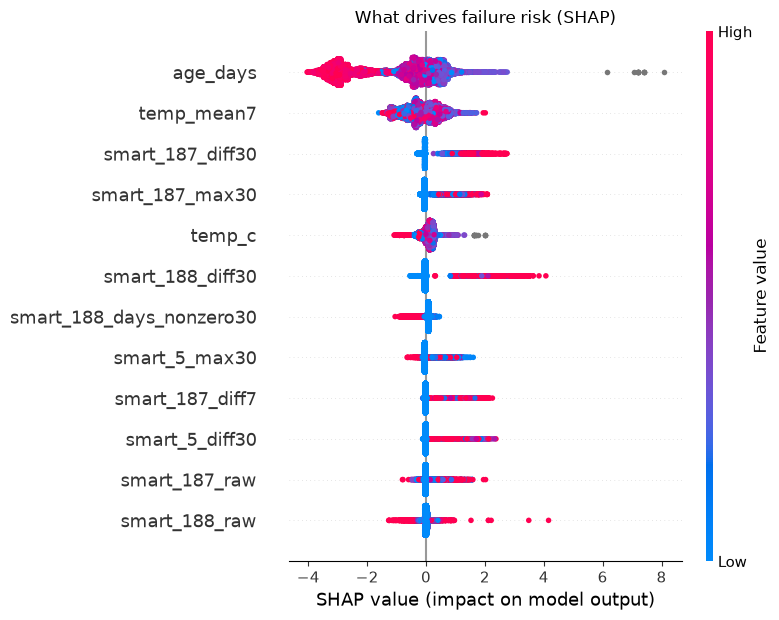

In [2]:
sample = pl.concat([
    test.filter(pl.col("label") == 1),
    test.filter(pl.col("label") == 0).sample(n=20000, seed=42),
])
X_s = sample.select(FEATURES).to_pandas()
sv = explainer.shap_values(X_s)
if isinstance(sv, list):
    sv = sv[1]

shap.summary_plot(sv, X_s, max_display=12, show=False)
plt.title("What drives failure risk (SHAP)")
plt.tight_layout()
plt.savefig(ROOT / "images" / "shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

In [3]:
NAMES = {
    "smart_5": "reallocated (bad) sectors", "smart_187": "uncorrectable errors",
    "smart_188": "command timeouts", "smart_197": "pending sectors",
    "smart_198": "offline uncorrectable sectors",
}

def describe(feat, value):
    for k, name in NAMES.items():
        if feat.startswith(k + "_"):
            if feat.endswith("_diff7"):  return f"{name} rose by {value:,.0f} in the last 7 days"
            if feat.endswith("_diff30"): return f"{name} rose by {value:,.0f} in the last 30 days"
            if feat.endswith("_max30"):  return f"{name} peaked at {value:,.0f} in the last 30 days"
            if feat.endswith("_days_nonzero30"): return f"{name} reported on {value:.0f} of the last 30 days"
            if feat.endswith("_raw"):    return f"{name} = {value:,.0f}"
    if feat == "age_days":   return f"drive age {value/365:.1f} years"
    if feat == "temp_c":     return f"temperature {value:.0f}°C"
    if feat == "temp_mean7": return f"7-day average temperature {value:.0f}°C"
    if feat == "gap_days":   return f"{value:.0f} days since previous report"
    return f"{feat} = {value}"

def explain_drive(serial, top=3):
    row = test.filter(pl.col("serial_number") == serial).sort("date").tail(1)
    x = row.select(FEATURES).to_pandas()
    s = explainer.shap_values(x)
    s = (s[1] if isinstance(s, list) else s)[0]
    print(f"Drive {serial} | {row['date'][0]} | risk score {row['score'][0]:.3f}")
    for i in np.argsort(-s)[:top]:
        if s[i] > 0:
            print("  ↑", describe(FEATURES[i], x.iloc[0, i]))

top_risk = (test.sort("date").group_by("serial_number").agg(pl.all().last())
                .sort("score", descending=True).head(5))
for sn in top_risk["serial_number"]:
    explain_drive(sn)
    print()

Drive ZHZ62FP0 | 2026-05-04 | risk score 0.999
  ↑ command timeouts rose by 184,697,356,498 in the last 30 days
  ↑ uncorrectable errors rose by 625 in the last 30 days
  ↑ 4 days since previous report

Drive ZHZ4RPT3 | 2026-04-22 | risk score 0.998
  ↑ command timeouts rose by 210,457,919,557 in the last 30 days
  ↑ uncorrectable errors rose by 283 in the last 30 days
  ↑ 4 days since previous report

Drive ZL0052YT | 2026-05-11 | risk score 0.998
  ↑ command timeouts rose by 188,996,518,162 in the last 30 days
  ↑ uncorrectable errors rose by 256 in the last 30 days
  ↑ uncorrectable errors rose by 180 in the last 7 days

Drive ZL0052LC | 2026-06-25 | risk score 0.998
  ↑ uncorrectable errors rose by 374 in the last 30 days
  ↑ uncorrectable errors rose by 292 in the last 7 days
  ↑ pending sectors rose by 135,584 in the last 30 days

Drive ZHZ2AP9A | 2026-04-07 | risk score 0.997
  ↑ pending sectors rose by 2,280 in the last 30 days
  ↑ uncorrectable errors rose by 440 in the last 3

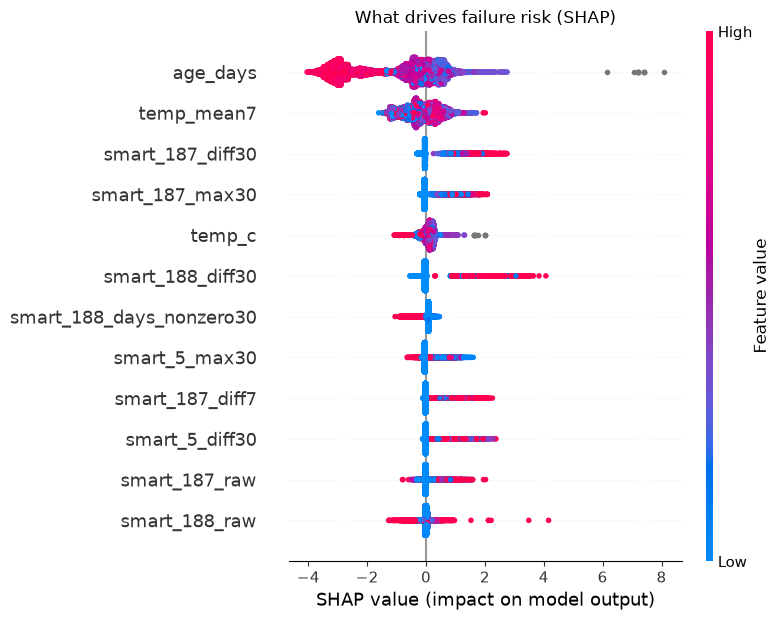

In [4]:
sample = pl.concat([
    test.filter(pl.col("label") == 1),
    test.filter(pl.col("label") == 0).sample(n=20000, seed=42),
])
X_s = sample.select(FEATURES).to_pandas()
sv = explainer.shap_values(X_s)
if isinstance(sv, list):
    sv = sv[1]

shap.summary_plot(sv, X_s, max_display=12, show=False)
plt.title("What drives failure risk (SHAP)")
plt.tight_layout()
plt.savefig(ROOT / "images" / "shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()